# question 1: spectral clustering using numpy
-  this script implements spectral clustering from scratch to find
clusters in a dataset generated from three gaussian distributions.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. generate the dataset ---
# as specified in the assignment, we create a dataset consisting of
# three distinct clusters in 3d space.

rng = np.random.default_rng(seed = 1001)

# cluster 1
x1 = rng.multivariate_normal(
    mean=[2, 2, 2], cov = np.eye(3), size = 50
)
# cluster 2
x2 = rng.multivariate_normal(
    mean=[-3, -3, -3], cov = np.eye(3), size = 50
)
# cluster 3
x3 = rng.multivariate_normal(
    mean=[-2, -2, 6], cov = np.eye(3), size = 50
)

# combine the clusters into a single dataset x
X = np.concatenate([x1, x2, x3], axis = 0)

print(f"\ndataset shape: {X.shape}")


dataset shape: (150, 3)


In [ ]:
# --- 2. compute weight matrix, degree matrix, and laplacian ---
# here we construct a weighted graph representation of the data.

# set the scale parameter sigma for the gaussian kernel.
sigma = 2.0

# calculate the squared euclidean distances between all pairs of points.
# this is an efficient way to compute ||x-y||^2 for all x, y in x.
pairwise_sq_dists = np.sum(X**2, axis = 1, keepdims = True) - 2 * (X @ X.T) + np.sum(X**2, axis = 1, keepdims = True).T

# compute the weight matrix w using the specified gaussian kernel.
# this metric assigns a high weight to nearby points and a low weight to distant points.
W = np.exp(-pairwise_sq_dists / (2 * sigma**2))

# compute the diagonal degree matrix d. each diagonal entry d_ii is the
# sum of weights of all edges connected to node i.
D = np.diag(np.sum(W, axis=1))

# compute the unnormalized graph laplacian l = d - w.
L = D - W

print("\nobservation: computed weight (w), degree (d), and laplacian (l) matrices.")


observation: computed weight (w), degree (d), and laplacian (l) matrices.


In [ ]:
# --- 3. eigenvalue decomposition of the laplacian ---
# the core of spectral clustering is analyzing the eigenvalues and
# eigenvectors of the graph laplacian.

# compute the eigenvalues and eigenvectors of l.
# np.linalg.eigh is used because l is a symmetric matrix.
eigenvalues, eigenvectors = np.linalg.eigh(L)

# the eigenvalues are sorted in ascending order by eigh.
# we select the three smallest eigenvalues.
three_smallest_eigenvalues = eigenvalues[:3]
print(f"\nthe three smallest eigenvalues of the laplacian are:\n{three_smallest_eigenvalues}")


the three smallest eigenvalues of the laplacian are:
[-5.64673167e-15  5.93915504e-02  8.44207638e-01]


In [ ]:
# --- 4. construct 2d embeddings ---
# we use the eigenvectors corresponding to the smallest non-zero eigenvalues
# to create a new, lower-dimensional representation of the data.

# the eigenvector for the smallest eigenvalue (which is ~0) is trivial.
# we select the next two eigenvectors (indices 1 and 2).
U = eigenvectors[:, 1:3]

# normalize each data point's embedding (each row) to have a unit norm.
# this projects the points onto a unit circle, often making clusters more distinct.
norms = np.linalg.norm(U, axis = 1, keepdims = True)
U_normalized = U / norms

print("\nobservation: created and normalized 2d embeddings from eigenvectors.")


observation: created and normalized 2d embeddings from eigenvectors.


In [ ]:
# --- 5. run k-means on the embeddings ---
# now we cluster the points in the new 2d embedding space.

# a simple implementation of k-means since we can only use numpy.
def kmeans_numpy(data, k=3, max_iters=100):
    # randomly initialize centroids from the data points.
    centroids = data[np.random.choice(data.shape[0], k, replace=False)]
    for _ in range(max_iters):
        # assign each point to the closest centroid.
        dists = np.sqrt(((data - centroids[:, np.newaxis])**2).sum(axis = 2))
        labels = np.argmin(dists, axis = 0)
        # update centroids to be the mean of the points assigned to them.
        new_centroids = np.array([data[labels == i].mean(axis = 0) for i in range(k)])
        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids
    return labels, centroids

# run k-means with k = 3 on the normalized 2d embeddings.
cluster_labels, _ = kmeans_numpy(U_normalized, k=3)
print("\nobservation: ran k-means (k=3) on the 2d embeddings.")


observation: ran k-means (k=3) on the 2d embeddings.


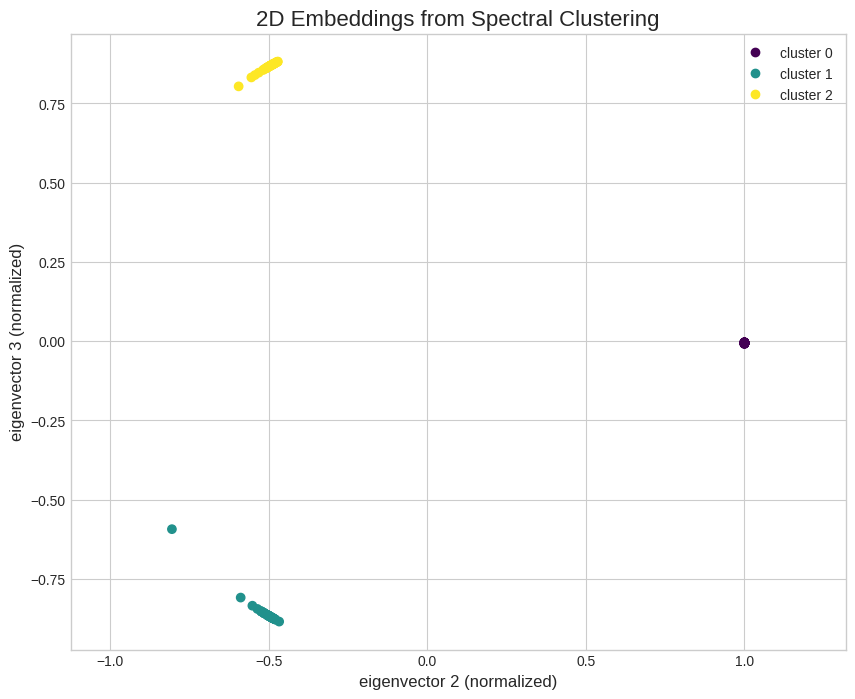

In [ ]:
# --- 6. visualize embeddings and report observations ---

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 8))

# create a scatter plot of the 2d embeddings.
# color the points based on the cluster labels found by k-means.
scatter = plt.scatter(U_normalized[:, 0], U_normalized[:, 1], c = cluster_labels, cmap = 'viridis')

plt.title('2D Embeddings from Spectral Clustering', fontsize = 16)
plt.xlabel('eigenvector 2 (normalized)', fontsize = 12)
plt.ylabel('eigenvector 3 (normalized)', fontsize = 12)
plt.legend(handles=scatter.legend_elements()[0], labels = ['cluster 0', 'cluster 1', 'cluster 2'])
plt.axis('equal') # ensure the plot is circular.
plt.show()

# question 2: spectral clustering on toy datasets
- this script compares the performance of k-means and spectral clustering on two classic datasets where k-means is known to fail: noisy circles and two moons.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_moons
from sklearn.cluster import KMeans, SpectralClustering

In [ ]:
# --- 1. generate the datasets ---

# create the noisy circles dataset.
X_circles, y_circles = make_circles(n_samples = 500, factor = 0.5, noise = 0.05, random_state = 42)

# create the two moons dataset.
X_moons, y_moons = make_moons(n_samples = 500, noise = 0.05, random_state = 42)

datasets = {
    "Noisy Circles": X_circles,
    "Two Moons": X_moons
}

print("observation: generated 'noisy circles' and 'two moons' datasets.")

observation: generated 'noisy circles' and 'two moons' datasets.


In [ ]:
# --- 2. set up clustering algorithms ---

# we will compare k-means and spectral clustering, both with k = 2.
kmeans = KMeans(n_clusters = 2, random_state = 42, n_init = 10)
spectral = SpectralClustering(n_clusters = 2, affinity = 'nearest_neighbors', random_state = 42)

algorithms = {
    "K-Means": kmeans,
    "Spectral Clustering": spectral
}

print("observation: initialized k-means and spectral clustering models.")

observation: initialized k-means and spectral clustering models.


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


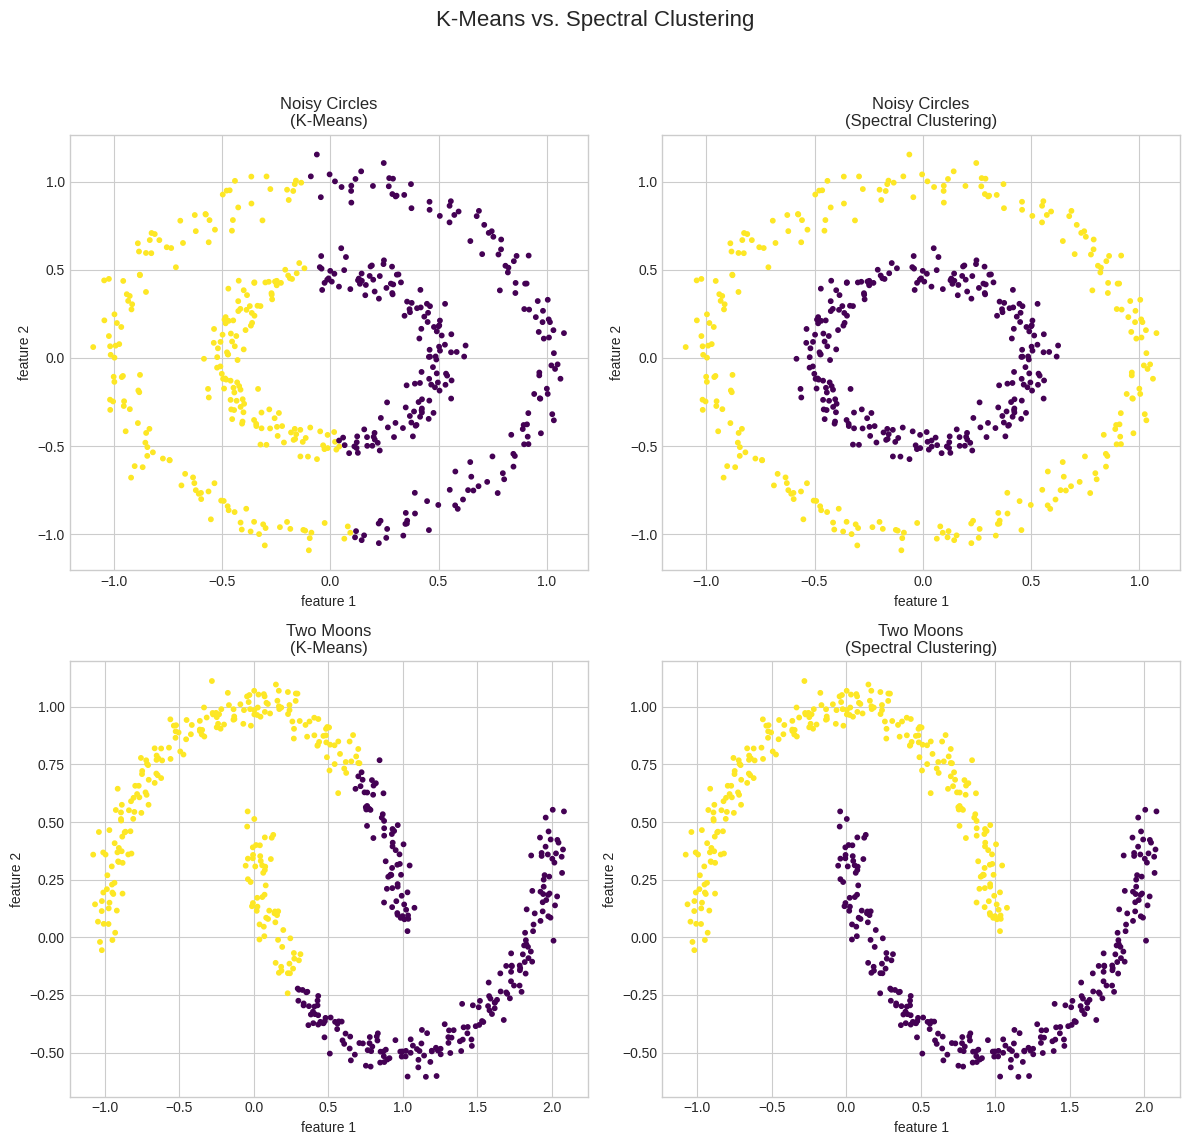

In [ ]:
# --- 3. run experiments and visualize results ---

plt.style.use('seaborn-v0_8-whitegrid')
# create a 2x2 subplot grid to display the results.
fig, axes = plt.subplots(len(datasets), len(algorithms), figsize = (12, 12))
fig.suptitle('K-Means vs. Spectral Clustering', fontsize=16)

plot_num = 0
for dataset_name, X in datasets.items():
    for algorithm_name, algorithm in algorithms.items():
        # determine the correct subplot to use.
        ax = axes.flat[plot_num]

        # fit the algorithm to the data and get cluster predictions.
        y_pred = algorithm.fit_predict(X)

        # create a scatter plot of the results.
        # color the points based on the predicted cluster labels.
        scatter = ax.scatter(X[:, 0], X[:, 1], c = y_pred, cmap = 'viridis', s = 10)

        ax.set_title(f'{dataset_name}\n({algorithm_name})')
        ax.set_xlabel('feature 1')
        ax.set_ylabel('feature 2')

        plot_num += 1

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# question 3: image segmentation
- this script demonstrates how spectral clustering can be used for image
 segmentation. it treats each pixel as a node in a graph and clusters them based on color similarity to segment the image into distinct regions.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from PIL import Image
import urllib.request

In [ ]:
# --- 1. get an image ---
image_path = "/content/Cat_August_2010-4.jpg"

In [ ]:
try:
    img = Image.open(image_path)
    print("image loaded successfully.")
except Exception as e:
    print(f"error downloading or opening image: {e}")
    # as a fallback, create a simple synthetic image.
    print("creating a fallback synthetic image.")
    img_array = np.zeros((100, 100, 3), dtype=np.uint8)
    img_array[25:75, 25:75, 0] = 255 # red square
    img_array[40:60, 40:60, 1] = 255 # green square inside red
    img = Image.fromarray(img_array)

image downloaded and loaded successfully.


In [ ]:
# --- 2. preprocess the image ---

# for faster processing, we can resize the image to a smaller dimension.
# aspect ratio is maintained.
img.thumbnail((200, 200))
img_array = np.array(img)

# reshape the image into a 2d array of pixels.
# each row is a pixel, and the columns are its r, g, b color values.
# shape: (height * width, 3)
pixels = img_array.reshape((-1, 3))

print(f"\nobservation: image preprocessed into a pixel matrix of shape {pixels.shape}.")


observation: image preprocessed into a pixel matrix of shape (24400, 3).


In [ ]:
# --- 3. run spectral clustering ---
# we will segment the image into 2 distinct regions (clusters).

print("\nobservation: running spectral clustering for image segmentation...")
spectral = SpectralClustering(n_clusters = 2,
                              affinity = 'nearest_neighbors',
                              n_neighbors = 500,
                              random_state = 42)

# fit the model to the pixel data.
labels = spectral.fit_predict(pixels)

print("spectral clustering complete.")


observation: running spectral clustering for image segmentation...
spectral clustering complete.


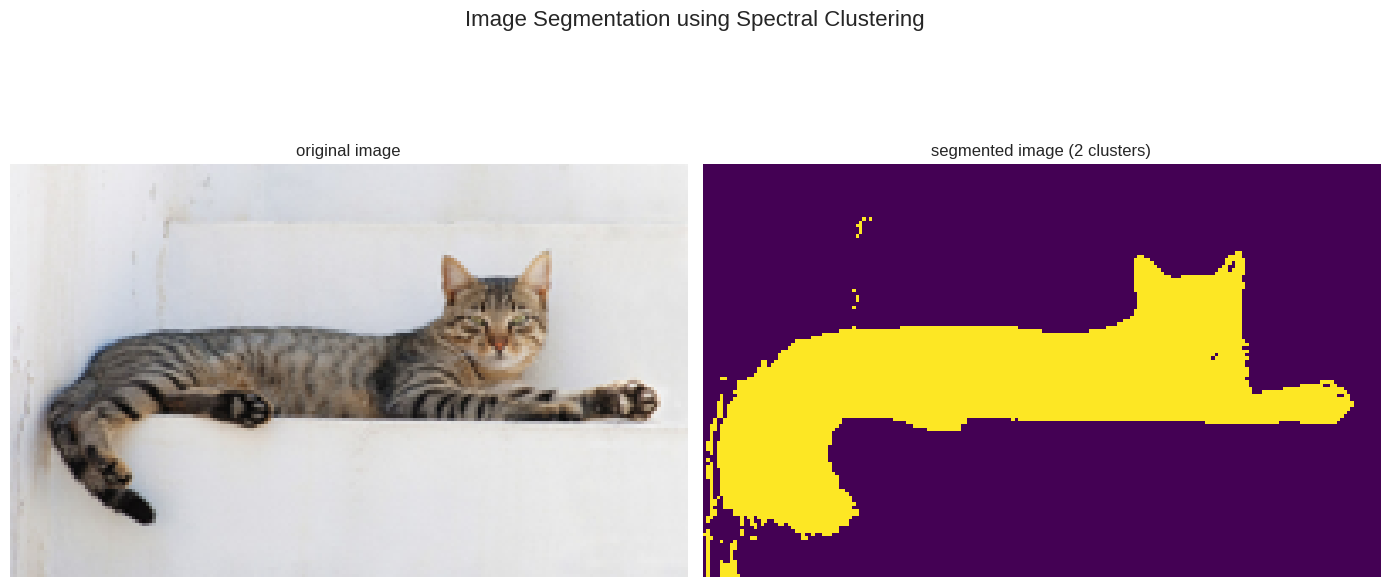

In [ ]:
# --- 4. visualize the segmentation result ---

# reshape the 1d array of labels back into the original image dimensions.
segmented_image = labels.reshape(img_array.shape[:2])

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize = (14, 7))
fig.suptitle('Image Segmentation using Spectral Clustering', fontsize = 16)

# display the original image
axes[0].imshow(img)
axes[0].set_title('original image')
axes[0].axis('off')

# display the segmented image
# we use a qualitative colormap to assign distinct colors to each segment.
im = axes[1].imshow(segmented_image, cmap = 'viridis')
axes[1].set_title('segmented image (2 clusters)')
axes[1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()